# Final Compound-Token Transformer (Next Song or SKIP)

This notebook is a clean final version for your project goal:
- **Input tokens**: song tokens (compound embedding = `song + genre`) and `SKIP` token.
- **Objective**: predict the next event as either `SKIP` or next song token.
- **Model**: causal Transformer with
  - song head: predicts next song token,
  - skip head: predicts whether next token is `SKIP`.

This two-head output keeps your compound-token idea while avoiding the common collapse where one flat softmax predicts `SKIP` for everything.


In [1]:
# Avoid torch re-registration crashes in notebooks when autoreload is enabled
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("autoreload", "0")
except Exception:
    pass

import os
import tarfile
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

import matplotlib.pyplot as plt

try:
    import ipywidgets  # noqa: F401
    from tqdm.notebook import tqdm
except Exception:
    # Fallback for environments without Jupyter widgets
    from tqdm import tqdm


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


CONFIG = {
    # Data
    "tar_path_candidates": [
        "./spotify_skip_prediction_mini.tar",
        "../spotify_skip_prediction_mini.tar",
    ],
    "extract_dir_candidates": ["./notebooks/extracted_files", "./extracted_files"],
    "log_rel_path": "data/training_set/log_mini.csv",
    "track_rel_path": "data/track_features/tf_mini.csv",

    # Columns
    "session_col": "session_id",
    "position_col": "session_position",
    "title_col_candidates": ["title", "track_name", "track_id_clean", "track_id"],
    "genre_col_candidates": ["genre", "genre_name", "track_genre"],
    "skip_col_candidates": ["skip_2", "skipped", "not_skipped"],

    # Split + vocab
    "test_size": 0.20,
    "val_size_within_train": 0.125,  # 12.5% of train partition
    "max_sessions": None,            # set e.g. 4000 for fast iteration
    "min_song_freq": 2,

    # Sequence + model
    "max_seq_len": 40,
    "d_model": 128,
    "nhead": 4,
    "num_layers": 2,
    "ff_dim": 256,
    "dropout": 0.10,

    # Optimization
    "batch_size": 256,
    "epochs": 8,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "skip_loss_weight": 6.0,

    # Threshold tuning
    "threshold_grid": np.linspace(0.0, 1.0, 101).tolist(),
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [2]:
def pick_first_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def pick_existing_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns found: {candidates}")
    return None


def load_spotify_data(config):
    extract_candidates = [Path(p) for p in config.get("extract_dir_candidates", ["./extracted_files"])]
    extract_dir = extract_candidates[0]
    for cand in extract_candidates:
        if (cand / config["log_rel_path"]).exists() and (cand / config["track_rel_path"]).exists():
            extract_dir = cand
            break

    log_path = extract_dir / config["log_rel_path"]
    tf_path = extract_dir / config["track_rel_path"]

    if not (log_path.exists() and tf_path.exists()):
        tar_path = pick_first_existing_path(config["tar_path_candidates"])
        if tar_path is None:
            raise FileNotFoundError("Could not find spotify tar file in tar_path_candidates")

        extract_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(path=extract_dir)
        print(f"Extracted {tar_path} -> {extract_dir}")

    print(f"Using log file: {log_path.resolve()}")
    print(f"Using track file: {tf_path.resolve()}")
    df_log = pd.read_csv(log_path)
    df_tf = pd.read_csv(tf_path)

    if "track_id_clean" in df_log.columns and "track_id" in df_tf.columns:
        df = pd.merge(df_log, df_tf, left_on="track_id_clean", right_on="track_id", how="left")
    elif "track_id" in df_log.columns and "track_id" in df_tf.columns:
        df = pd.merge(df_log, df_tf, on="track_id", how="left")
    else:
        raise KeyError("No compatible track ID columns found for merge.")

    return df


def build_event_table(df, config):
    session_col = config["session_col"]
    position_col = config["position_col"]

    if session_col not in df.columns or position_col not in df.columns:
        raise KeyError(f"Required columns missing: {session_col}, {position_col}")

    title_col = pick_existing_column(df, config["title_col_candidates"], required=True)
    genre_col = pick_existing_column(df, config["genre_col_candidates"], required=False)
    skip_col = pick_existing_column(df, config["skip_col_candidates"], required=True)

    out = df[[session_col, position_col, title_col]].copy()
    out["title"] = df[title_col].astype(str).fillna("<UNK_SONG>")

    if genre_col is None:
        out["genre"] = "<UNK_GENRE>"
    else:
        out["genre"] = df[genre_col].astype(str).fillna("<UNK_GENRE>")

    if skip_col == "not_skipped":
        out["skip"] = (~df[skip_col].astype(bool)).astype(int)
    else:
        out["skip"] = df[skip_col].astype(int)

    out = out.sort_values([session_col, position_col]).reset_index(drop=True)

    if config["max_sessions"] is not None:
        keep_sessions = out[session_col].drop_duplicates().head(config["max_sessions"])
        out = out[out[session_col].isin(set(keep_sessions))].copy()

    used = {
        "session_col": session_col,
        "position_col": position_col,
        "title_col": title_col,
        "genre_col": genre_col,
        "skip_col": skip_col,
    }
    return out, used


df_merged = load_spotify_data(CONFIG)
events_df, used_cols = build_event_table(df_merged, CONFIG)
print("events shape:", events_df.shape)
print("used columns:", used_cols)


Using log file: /Users/caroltu/stat4830real/STAT-4830-Vanishing-Gradients-project/notebooks/extracted_files/data/training_set/log_mini.csv
Using track file: /Users/caroltu/stat4830real/STAT-4830-Vanishing-Gradients-project/notebooks/extracted_files/data/track_features/tf_mini.csv
events shape: (167880, 6)
used columns: {'session_col': 'session_id', 'position_col': 'session_position', 'title_col': 'track_id_clean', 'genre_col': None, 'skip_col': 'skip_2'}


In [3]:
# Session-wise split: train / val / test
session_col = CONFIG["session_col"]

splitter_test = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG["test_size"],
    random_state=42,
)
train_idx, test_idx = next(splitter_test.split(events_df, groups=events_df[session_col]))

train_all_df = events_df.iloc[train_idx].copy()
test_df = events_df.iloc[test_idx].copy()

splitter_val = GroupShuffleSplit(
    n_splits=1,
    test_size=CONFIG["val_size_within_train"],
    random_state=42,
)
train2_idx, val_idx = next(splitter_val.split(train_all_df, groups=train_all_df[session_col]))

train_df = train_all_df.iloc[train2_idx].copy()
val_df = train_all_df.iloc[val_idx].copy()

print("Train rows:", len(train_df), "Val rows:", len(val_df), "Test rows:", len(test_df))
print("Train sessions:", train_df[session_col].nunique(),
      "Val sessions:", val_df[session_col].nunique(),
      "Test sessions:", test_df[session_col].nunique())


Train rows: 117297 Val rows: 16971 Test rows: 33612
Train sessions: 7000 Val sessions: 1000 Test sessions: 2000


In [4]:
# Build train vocab only
counts = train_df["title"].value_counts()
keep_titles = set(counts[counts >= CONFIG["min_song_freq"]].index.tolist())

song_to_idx = {"<UNK_SONG>": 0}
for t in sorted(keep_titles):
    if t != "<UNK_SONG>":
        song_to_idx[t] = len(song_to_idx)

genre_to_idx = {"<NONE>": 0, "<UNK_GENRE>": 1}
for g in sorted(train_df["genre"].dropna().astype(str).unique().tolist()):
    if g not in genre_to_idx:
        genre_to_idx[g] = len(genre_to_idx)

# Song-level genre map from train only
song_genre = {}
tmp = train_df.copy()
tmp["title_mapped"] = tmp["title"].where(tmp["title"].isin(keep_titles), "<UNK_SONG>")
for title, grp in tmp.groupby("title_mapped"):
    g_mode = grp["genre"].astype(str).mode()
    genre = g_mode.iloc[0] if len(g_mode) > 0 else "<UNK_GENRE>"
    if genre not in genre_to_idx:
        genre = "<UNK_GENRE>"
    song_genre[title] = genre

if "<UNK_SONG>" not in song_genre:
    song_genre["<UNK_SONG>"] = "<UNK_GENRE>"


def encode_events(df):
    out = df.copy()
    out["title_mapped"] = out["title"].where(out["title"].isin(keep_titles), "<UNK_SONG>")
    out["song_idx"] = out["title_mapped"].map(song_to_idx).fillna(0).astype(np.int64)
    out["skip"] = out["skip"].astype(np.int64)
    return out


train_enc = encode_events(train_df)
val_enc = encode_events(val_df)
test_enc = encode_events(test_df)

print("song vocab size:", len(song_to_idx))
print("genre vocab size:", len(genre_to_idx))


song vocab size: 14045
genre vocab size: 2


In [5]:
# Sequence construction
# Token ids:
# 0 = PAD
# 1 = SKIP
# 2.. = song tokens


def build_session_sequences(df, session_col, position_col):
    seqs = []
    grouped = df.sort_values([session_col, position_col]).groupby(session_col, sort=False)

    for _, grp in grouped:
        s = []
        for song_idx, sk in zip(grp["song_idx"].to_numpy(np.int64), grp["skip"].to_numpy(np.int64)):
            song_token = int(song_idx) + 2
            s.append(song_token)
            if sk == 1:
                s.append(1)

        if len(s) >= 2:
            seqs.append(s)

    return seqs


train_seqs = build_session_sequences(train_enc, CONFIG["session_col"], CONFIG["position_col"])
val_seqs = build_session_sequences(val_enc, CONFIG["session_col"], CONFIG["position_col"])
test_seqs = build_session_sequences(test_enc, CONFIG["session_col"], CONFIG["position_col"])


# Next-token examples
# Each row predicts one next token from a left-padded history window.
def make_next_token_examples(sequences, max_seq_len, pad_token_id=0):
    n = sum(max(0, len(seq) - 1) for seq in sequences)

    X = np.full((n, max_seq_len), pad_token_id, dtype=np.int64)
    A = np.zeros((n, max_seq_len), dtype=np.int64)
    y = np.zeros(n, dtype=np.int64)

    i = 0
    for seq in sequences:
        for t in range(1, len(seq)):
            hist = seq[max(0, t - max_seq_len):t]
            L = len(hist)
            # Right padding avoids fully-masked rows with causal + padding masks.
            X[i, :L] = np.array(hist, dtype=np.int64)
            A[i, :L] = 1
            y[i] = seq[t]
            i += 1

    return X, A, y


X_train, A_train, y_train = make_next_token_examples(train_seqs, CONFIG["max_seq_len"])
X_val, A_val, y_val = make_next_token_examples(val_seqs, CONFIG["max_seq_len"])
X_test, A_test, y_test = make_next_token_examples(test_seqs, CONFIG["max_seq_len"])

# Sanity checks
vocab_size = len(song_to_idx) + 2
assert y_train.min() >= 1 and y_val.min() >= 1 and y_test.min() >= 1
assert y_train.max() < vocab_size and y_val.max() < vocab_size and y_test.max() < vocab_size

print("Train examples:", len(y_train), "Val:", len(y_val), "Test:", len(y_test))
print("Train skip rate:", float(np.mean(y_train == 1)))
print("Val skip rate:", float(np.mean(y_val == 1)))
print("Test skip rate:", float(np.mean(y_test == 1)))


Train examples: 170840 Val: 24640 Test: 49224
Train skip rate: 0.3543842191524233
Val skip rate: 0.3518262987012987
Test skip rate: 0.35779294653014787


In [6]:
class NextTokenDataset(Dataset):
    def __init__(self, X, A, y):
        self.X = torch.from_numpy(X).long()
        self.A = torch.from_numpy(A).long()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.y.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.A[idx], self.y[idx]


train_ds = NextTokenDataset(X_train, A_train, y_train)
val_ds = NextTokenDataset(X_val, A_val, y_val)
test_ds = NextTokenDataset(X_test, A_test, y_test)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)


## Model

Token embedding is exactly your compound-token pattern:

- For song token: `E_song(title) + E_genre(genre) + E_pos`
- For skip token: `E_skip + E_pos`

Output heads:
- `song_head`: next-song token distribution (over song tokens only)
- `skip_head`: probability next token is `SKIP`

Final decoded next token:
- if `p(skip) >= threshold` -> `SKIP`
- else -> argmax song token


In [7]:
# token -> feature lookup tables
# song feature index: 0 reserved for PAD/SKIP; songs shifted by +1

token_to_song_feature = np.zeros(vocab_size, dtype=np.int64)
token_to_genre = np.zeros(vocab_size, dtype=np.int64)

for title, sidx in song_to_idx.items():
    token_id = sidx + 2
    token_to_song_feature[token_id] = sidx + 1

    g = song_genre.get(title, "<UNK_GENRE>")
    token_to_genre[token_id] = genre_to_idx.get(g, genre_to_idx["<UNK_GENRE>"])


class CompoundTokenTransformer(nn.Module):
    def __init__(
        self,
        song_vocab_size,
        genre_vocab_size,
        token_to_song_feature,
        token_to_genre,
        d_model=128,
        nhead=4,
        num_layers=2,
        ff_dim=256,
        max_seq_len=40,
        dropout=0.1,
        skip_token_id=1,
    ):
        super().__init__()
        self.skip_token_id = skip_token_id

        self.song_emb = nn.Embedding(song_vocab_size, d_model)
        self.genre_emb = nn.Embedding(genre_vocab_size, d_model)
        self.skip_emb = nn.Parameter(torch.zeros(d_model))
        nn.init.normal_(self.skip_emb, mean=0.0, std=0.02)

        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Song classes correspond to token ids 2..vocab_size-1
        self.song_head = nn.Linear(d_model, vocab_size - 2)
        self.skip_head = nn.Linear(d_model, 1)

        self.register_buffer("token_to_song_feature", torch.tensor(token_to_song_feature, dtype=torch.long))
        self.register_buffer("token_to_genre", torch.tensor(token_to_genre, dtype=torch.long))

    def _causal_mask(self, seq_len, device):
        return torch.triu(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool), diagonal=1)

    def encode_last(self, token_ids, attention_mask):
        B, L = token_ids.shape

        song_ids = self.token_to_song_feature[token_ids]
        genre_ids = self.token_to_genre[token_ids]

        song_embed = self.song_emb(song_ids) + self.genre_emb(genre_ids)
        x = torch.where(
            (token_ids == self.skip_token_id).unsqueeze(-1),
            self.skip_emb.view(1, 1, -1),
            song_embed,
        )

        pos_ids = torch.arange(L, device=token_ids.device).unsqueeze(0)
        x = self.dropout(x + self.pos_emb(pos_ids))

        h = self.encoder(
            x,
            mask=self._causal_mask(L, token_ids.device),
            src_key_padding_mask=(attention_mask == 0),
        )

        # With right-padded inputs, the final valid token is at length-1.
        last_idx = attention_mask.sum(dim=1).clamp(min=1) - 1
        last_h = h[torch.arange(B, device=token_ids.device), last_idx]
        return last_h

    def forward(self, token_ids, attention_mask):
        h = self.encode_last(token_ids, attention_mask)
        song_logits = self.song_head(h)
        skip_logit = self.skip_head(h).squeeze(1)
        return song_logits, skip_logit


model = CompoundTokenTransformer(
    song_vocab_size=len(song_to_idx) + 1,  # +1 for reserved non-song id 0
    genre_vocab_size=len(genre_to_idx),
    token_to_song_feature=token_to_song_feature,
    token_to_genre=token_to_genre,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_layers=CONFIG["num_layers"],
    ff_dim=CONFIG["ff_dim"],
    max_seq_len=CONFIG["max_seq_len"],
    dropout=CONFIG["dropout"],
).to(DEVICE)

model


/var/folders/f_/ltygyh2d33x4m6tkm0zzxw4h0000gn/T/ipykernel_59024/1491358625.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


CompoundTokenTransformer(
  (song_emb): Embedding(14046, 128)
  (genre_emb): Embedding(2, 128)
  (pos_emb): Embedding(40, 128)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (song_head): Linear(in_features=128, out_features=14045, bias=True)
  (skip_head): Linear(in_features=128, out_features=1, 

In [8]:
# Losses + threshold utilities

song_loss_fn = nn.CrossEntropyLoss()
# CE can be numerically much larger than BCE with many song classes.
# Normalize CE so skip head is not drowned out.
song_ce_scale = max(1.0, float(np.log(max(vocab_size - 2, 2))))

train_skip_rate = float(np.mean(y_train == 1))
# Balance positive skip class in BCE
pos_weight = (1.0 - train_skip_rate) / max(train_skip_rate, 1e-6)
skip_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE))
print(f"skip pos_weight: {pos_weight:.4f} | song_ce_scale: {song_ce_scale:.4f} | skip_loss_weight: {CONFIG['skip_loss_weight']}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)


def decode_with_threshold(skip_prob, pred_song_token, threshold):
    return np.where(skip_prob >= threshold, 1, pred_song_token)


def compute_token_metrics(y_true, pred_token):
    overall_acc = float(accuracy_score(y_true, pred_token))

    song_mask = y_true != 1
    song_acc = float(accuracy_score(y_true[song_mask], pred_token[song_mask])) if song_mask.any() else 0.0

    y_skip = (y_true == 1).astype(int)
    p_skip = (pred_token == 1).astype(int)
    sp, sr, sf1, _ = precision_recall_fscore_support(y_skip, p_skip, average="binary", zero_division=0)

    return {
        "overall_acc": overall_acc,
        "song_acc": song_acc,
        "skip_precision": float(sp),
        "skip_recall": float(sr),
        "skip_f1": float(sf1),
        "pred_skip_rate": float(np.mean(p_skip)),
        "true_skip_rate": float(np.mean(y_skip)),
    }


def evaluate_model(model, loader, threshold=0.5):
    model.eval()

    ys = []
    pred_song_tokens = []
    skip_probs = []

    total_loss = 0.0
    seen = 0
    loss_seen = 0
    song_top5_hits = []

    with torch.no_grad():
        for x, a, y in loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y = y.to(DEVICE)

            song_logits, skip_logit = model(x, a)
            song_logits = torch.nan_to_num(song_logits, nan=0.0, posinf=1e4, neginf=-1e4)
            skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

            # Joint training loss report
            y_skip = (y == 1).float()
            loss_skip = skip_loss_fn(skip_logit, y_skip)

            song_mask = (y != 1)
            if song_mask.any():
                y_song = (y[song_mask] - 2).clamp(min=0)
                loss_song = song_loss_fn(song_logits[song_mask], y_song)
                loss = (loss_song / song_ce_scale) + CONFIG["skip_loss_weight"] * loss_skip
            else:
                loss = CONFIG["skip_loss_weight"] * loss_skip

            if torch.isfinite(loss):
                total_loss += float(loss.item()) * y.size(0)
                loss_seen += y.size(0)
            seen += y.size(0)

            prob_skip = torch.sigmoid(skip_logit).cpu().numpy()
            pred_song = (torch.argmax(song_logits, dim=1) + 2).cpu().numpy()
            y_np = y.cpu().numpy()

            ys.append(y_np)
            pred_song_tokens.append(pred_song)
            skip_probs.append(prob_skip)

            # Song top-5 on true song targets
            sm_np = y_np != 1
            if sm_np.any():
                topk = min(5, song_logits.size(1))
                top5_song = torch.topk(song_logits[sm_np], k=topk, dim=1).indices.cpu().numpy() + 2
                hits = (top5_song == y_np[sm_np][:, None]).any(axis=1).astype(np.int64)
                song_top5_hits.append(hits)

    y_true = np.concatenate(ys)
    pred_song = np.concatenate(pred_song_tokens)
    skip_prob = np.concatenate(skip_probs)

    pred_token = decode_with_threshold(skip_prob, pred_song, threshold)
    metrics = compute_token_metrics(y_true, pred_token)
    metrics["loss"] = total_loss / max(loss_seen, 1)
    metrics["loss_finite_frac"] = float(loss_seen / max(seen, 1))
    metrics["song_top5_acc"] = float(np.mean(np.concatenate(song_top5_hits))) if len(song_top5_hits) > 0 else 0.0
    metrics["skip_prob_mean"] = float(np.mean(skip_prob))
    metrics["skip_prob_std"] = float(np.std(skip_prob))

    return metrics, y_true, pred_song, skip_prob


def tune_threshold(y_true, pred_song, skip_prob, threshold_grid):
    target_skip_rate = float(np.mean(y_true == 1))
    candidates = [float(t) for t in threshold_grid]
    if len(skip_prob) > 0:
        q = max(0.0, min(1.0, 1.0 - target_skip_rate))
        candidates.append(float(np.quantile(skip_prob, q)))
        candidates.extend([0.0, 1.0])
    candidates = sorted(set(candidates))

    best_thr = 0.5
    best_score = -1e9
    best_metrics = None

    for thr in candidates:
        pred_token = decode_with_threshold(skip_prob, pred_song, float(thr))
        m = compute_token_metrics(y_true, pred_token)
        rate_penalty = abs(m["pred_skip_rate"] - target_skip_rate)
        score = 0.60 * m["song_acc"] + 0.40 * m["skip_f1"] - 0.20 * rate_penalty

        # discourage trivial all-song / all-skip collapse
        if (m["pred_skip_rate"] < 0.01 or m["pred_skip_rate"] > 0.99) and m["skip_f1"] < 0.05:
            score -= 1.0

        if score > best_score:
            best_score = score
            best_thr = float(thr)
            best_metrics = m

    # Hard fallback: if skip F1 collapsed to zero, force prevalence-matching threshold
    if best_metrics is not None and best_metrics["skip_f1"] <= 1e-8 and len(skip_prob) > 0:
        q = max(0.0, min(1.0, 1.0 - target_skip_rate))
        prevalence_thr = float(np.quantile(skip_prob, q))
        pred_token = decode_with_threshold(skip_prob, pred_song, prevalence_thr)
        return prevalence_thr, compute_token_metrics(y_true, pred_token)

    return best_thr, best_metrics


skip pos_weight: 1.8218 | song_ce_scale: 9.5500 | skip_loss_weight: 6.0


In [9]:
# Train
history = []

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    running = 0.0
    seen = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CONFIG['epochs']}", leave=True, dynamic_ncols=True)
    for x, a, y in pbar:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        song_logits, skip_logit = model(x, a)
        song_logits = torch.nan_to_num(song_logits, nan=0.0, posinf=1e4, neginf=-1e4)
        skip_logit = torch.nan_to_num(skip_logit, nan=0.0, posinf=1e4, neginf=-1e4)

        y_skip = (y == 1).float()
        loss_skip = skip_loss_fn(skip_logit, y_skip)

        song_mask = (y != 1)
        if song_mask.any():
            y_song = (y[song_mask] - 2).clamp(min=0)
            loss_song = song_loss_fn(song_logits[song_mask], y_song)
            loss = (loss_song / song_ce_scale) + CONFIG["skip_loss_weight"] * loss_skip
        else:
            loss = CONFIG["skip_loss_weight"] * loss_skip

        if not torch.isfinite(loss):
            pbar.set_postfix({"batch_loss": "nan/inf"})
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        bs = y.size(0)
        running += float(loss.item()) * bs
        seen += bs
        pbar.set_postfix({"batch_loss": f"{float(loss.item()):.4f}"})

    train_loss = running / max(seen, 1)

    # Tune decision threshold on validation set
    val_raw, y_val_true, val_pred_song, val_skip_prob = evaluate_model(model, val_loader, threshold=0.5)
    tuned_thr, _ = tune_threshold(y_val_true, val_pred_song, val_skip_prob, CONFIG["threshold_grid"])

    val_metrics, _, _, _ = evaluate_model(model, val_loader, threshold=tuned_thr)
    test_metrics, _, _, _ = evaluate_model(model, test_loader, threshold=tuned_thr)

    row = {
        "epoch": epoch,
        "threshold": tuned_thr,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "test_loss": test_metrics["loss"],
        "val_acc": val_metrics["overall_acc"],
        "test_acc": test_metrics["overall_acc"],
        "val_song_acc": val_metrics["song_acc"],
        "test_song_acc": test_metrics["song_acc"],
        "val_song_top5": val_metrics["song_top5_acc"],
        "test_song_top5": test_metrics["song_top5_acc"],
        "val_skip_f1": val_metrics["skip_f1"],
        "test_skip_f1": test_metrics["skip_f1"],
        "test_pred_skip_rate": test_metrics["pred_skip_rate"],
        "test_true_skip_rate": test_metrics["true_skip_rate"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"test_loss={test_metrics['loss']:.4f} | "
        f"test_acc={test_metrics['overall_acc']:.4f} | "
        f"song_acc={test_metrics['song_acc']:.4f} | "
        f"song_top5={test_metrics['song_top5_acc']:.4f} | "
        f"skip_F1={test_metrics['skip_f1']:.4f} | "
        f"skip_rate_pred={test_metrics['pred_skip_rate']:.4f} | "
        f"skip_prob_mean={test_metrics['skip_prob_mean']:.4f} | "
        f"skip_prob_std={test_metrics['skip_prob_std']:.4f}"
    )

history_df = pd.DataFrame(history)
display(history_df.round(4))


Epoch 1/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 01 | train_loss=4.0825 | val_loss=3.5997 | test_loss=3.6396 | test_acc=0.4639 | song_acc=0.3102 | song_top5=0.3913 | skip_F1=0.7422 | skip_rate_pred=0.3555 | skip_prob_mean=0.4396 | skip_prob_std=0.3596


Epoch 2/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 02 | train_loss=3.7702 | val_loss=3.5729 | test_loss=3.6213 | test_acc=0.4655 | song_acc=0.3163 | song_top5=0.4009 | skip_F1=0.7408 | skip_rate_pred=0.3506 | skip_prob_mean=0.4368 | skip_prob_std=0.3692


Epoch 3/8:   0%|          | 0/668 [00:00<?, ?it/s]

...

Epoch 7/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 07 | train_loss=3.4872 | val_loss=3.5851 | test_loss=3.6377 | test_acc=0.4719 | song_acc=0.3233 | song_top5=0.4245 | skip_F1=0.7385 | skip_rate_pred=0.3579 | skip_prob_mean=0.4449 | skip_prob_std=0.3724


Epoch 8/8:   0%|          | 0/668 [00:00<?, ?it/s]

Epoch 08 | train_loss=3.4357 | val_loss=3.5972 | test_loss=3.6586 | test_acc=0.4761 | song_acc=0.3294 | song_top5=0.4276 | skip_F1=0.7392 | skip_rate_pred=0.3580 | skip_prob_mean=0.4516 | skip_prob_std=0.3768


,epoch,threshold,train_loss,val_loss,test_loss,val_acc,test_acc,val_song_acc,test_song_acc,val_song_top5,test_song_top5,val_skip_f1,test_skip_f1,test_pred_skip_rate,test_true_skip_rate
0,1,0.6621,4.0825,3.5997,3.6396,0.4803,0.4639,0.3361,0.3102,0.4154,0.3913,0.7459,0.7422,0.3555,0.3578
1,2,0.6900,3.7702,3.5729,3.6213,0.4836,0.4655,0.3441,0.3163,0.4264,0.4009,0.7474,0.7408,0.3506,0.3578
2,3,0.6180,3.6971,3.5459,3.6007,0.4876,0.4711,0.3461,0.3189,0.4313,0.4065,0.7484,0.7450,0.3570,0.3578
3,4,0.6011,3.6397,3.5879,3.6489,0.4903,0.4725,0.3495,0.3217,0.4366,0.4122,0.7497,0.7438,0.3573,0.3578
4,5,0.6330,3.5864,3.5477,3.6022,0.4912,0.4735,0.3514,0.3229,0.4395,0.4171,0.7488,0.7432,0.3582,0.3578
5,6,0.6800,3.5364,3.5931,3.6497,0.4895,0.4722,0.3504,0.3240,0.4416,0.4204,0.7470,0.7410,0.3552,0.3578
6,7,0.6769,3.4872,3.5851,3.6377,0.4871,0.4719,0.3485,0.3233,0.4467,0.4245,0.7425,0.7385,0.3579,0.3578
7,8,0.6879,3.4357,3.5972,3.6586,0.4914,0.4761,0.3535,0.3294,0.4491,0.4276,0.7454,0.7392,0.3580,0.3578


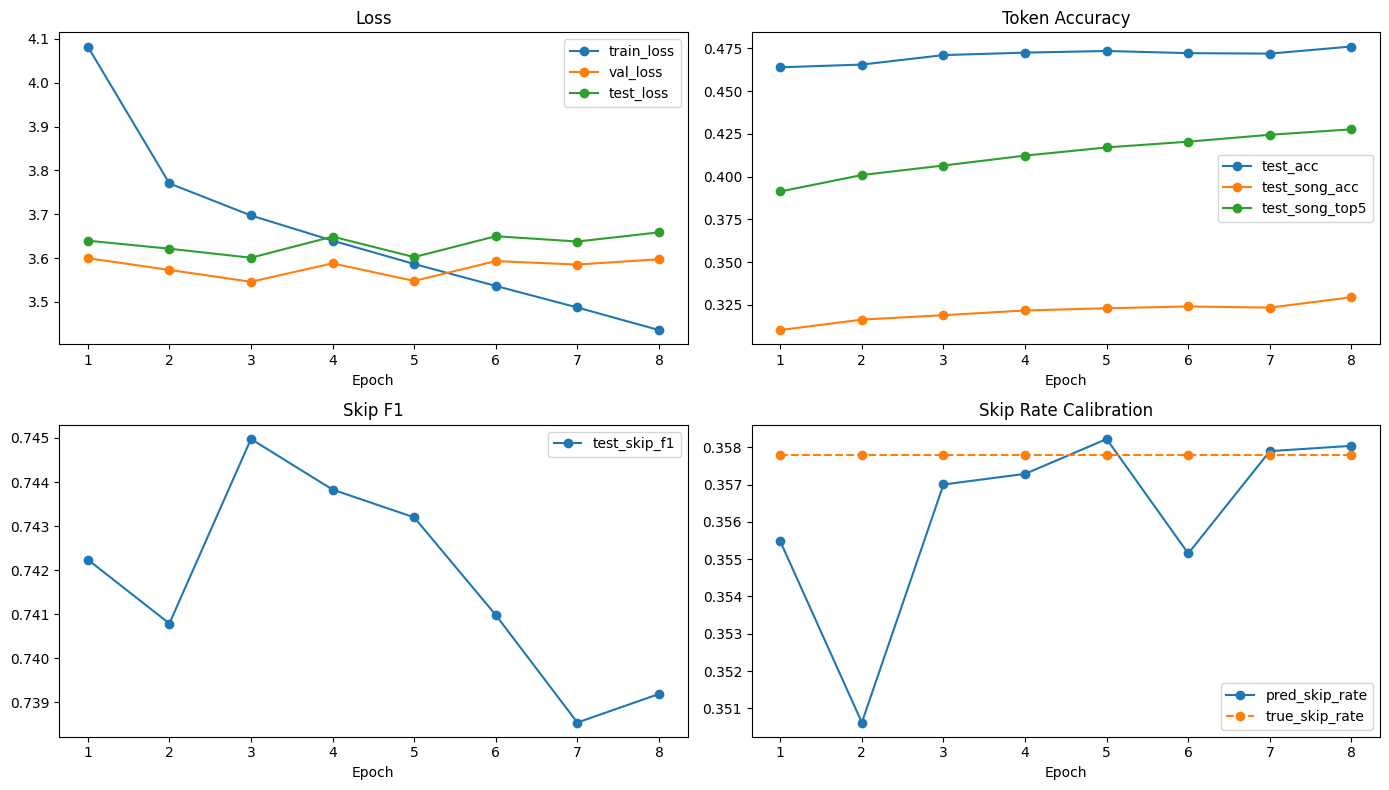

In [10]:
# Curves
if len(history_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    axes[0, 0].plot(history_df["epoch"], history_df["test_loss"], marker="o", label="test_loss")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend()

    axes[0, 1].plot(history_df["epoch"], history_df["test_acc"], marker="o", label="test_acc")
    axes[0, 1].plot(history_df["epoch"], history_df["test_song_acc"], marker="o", label="test_song_acc")
    axes[0, 1].plot(history_df["epoch"], history_df["test_song_top5"], marker="o", label="test_song_top5")
    axes[0, 1].set_title("Token Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()

    axes[1, 0].plot(history_df["epoch"], history_df["test_skip_f1"], marker="o", label="test_skip_f1")
    axes[1, 0].set_title("Skip F1")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend()

    axes[1, 1].plot(history_df["epoch"], history_df["test_pred_skip_rate"], marker="o", label="pred_skip_rate")
    axes[1, 1].plot(history_df["epoch"], history_df["test_true_skip_rate"], marker="o", linestyle="--", label="true_skip_rate")
    axes[1, 1].set_title("Skip Rate Calibration")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


Final threshold: 0.6879
Final test metrics:
  loss: 3.6586
  overall_acc: 0.4761
  song_acc: 0.3294
  song_top5_acc: 0.4276
  skip_precision: 0.7389
  skip_recall: 0.7394
  skip_f1: 0.7392
  pred_skip_rate: 0.3580
  true_skip_rate: 0.3578


,model,overall_acc,song_acc,skip_precision,skip_recall,skip_f1,pred_skip_rate,true_skip_rate
0,baseline_always_skip,0.3578,0.0000,0.3578,1.0000,0.5270,1.000,0.3578
1,baseline_mode_song,0.2293,0.3571,0.0000,0.0000,0.0000,0.000,0.3578
2,transformer_compound,0.4761,0.3294,0.7389,0.7394,0.7392,0.358,0.3578


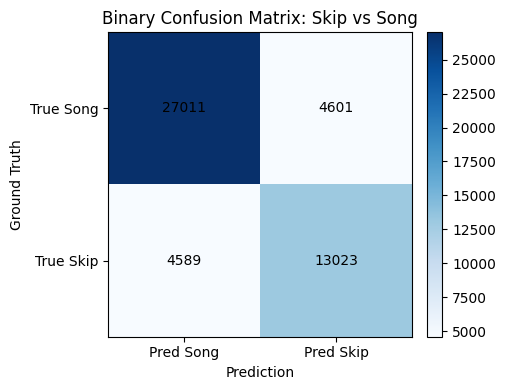

In [11]:
# Final test report with tuned threshold from last epoch
final_threshold = float(history_df.iloc[-1]["threshold"]) if len(history_df) > 0 else 0.5
final_metrics, y_true, pred_song, skip_prob = evaluate_model(model, test_loader, threshold=final_threshold)
y_pred = decode_with_threshold(skip_prob, pred_song, final_threshold)

print("Final threshold:", round(final_threshold, 4))
print("Final test metrics:")
for k in ["loss", "overall_acc", "song_acc", "song_top5_acc", "skip_precision", "skip_recall", "skip_f1", "pred_skip_rate", "true_skip_rate"]:
    print(f"  {k}: {final_metrics[k]:.4f}")

# Baselines for professor presentation
baseline_rows = []

# Baseline 1: always SKIP
pred_all_skip = np.ones_like(y_true)
m_skip = compute_token_metrics(y_true, pred_all_skip)
baseline_rows.append({"model": "baseline_always_skip", **m_skip})

# Baseline 2: always most frequent song token from train targets
song_targets_train = y_train[y_train != 1]
mode_song_token = int(pd.Series(song_targets_train).value_counts().index[0]) if len(song_targets_train) > 0 else 2
pred_mode_song = np.full_like(y_true, mode_song_token)
m_mode = compute_token_metrics(y_true, pred_mode_song)
baseline_rows.append({"model": "baseline_mode_song", **m_mode})

# Model row
baseline_rows.append({"model": "transformer_compound", **compute_token_metrics(y_true, y_pred)})

report_df = pd.DataFrame(baseline_rows)
show_cols = [
    "model", "overall_acc", "song_acc", "skip_precision", "skip_recall", "skip_f1", "pred_skip_rate", "true_skip_rate"
]
display(report_df[show_cols].round(4))

# Binary confusion matrix: skip vs song
cm = confusion_matrix((y_true == 1).astype(int), (y_pred == 1).astype(int), labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred Song", "Pred Skip"])
ax.set_yticks([0, 1], labels=["True Song", "True Skip"])
ax.set_title("Binary Confusion Matrix: Skip vs Song")
ax.set_xlabel("Prediction")
ax.set_ylabel("Ground Truth")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Notes

- This notebook is intentionally minimal and focused on your assignment objective.
- If you need faster iteration, set `CONFIG["max_sessions"]` to a smaller value (e.g., `3000`).
- If skip prediction is still weak, adjust `CONFIG["skip_loss_weight"]` modestly (start around `6.0`, then try `4.0` or `8.0`).
